# 078: Frontier Figure — Sensitivity × Throughput Positioning

Creates the "The frontier Kmerseek opens" figure: a scatter plot of methods on
family-level sensitivity (gray-zone, <40% id) vs throughput (queries/s, log scale),
plus a comparison table.

## Data sources

**Sensitivity (AUC):**
- Kmerseek: `~/data/scope/results-hp-alphabet-sweep/auc_sweep_bonf_jaccard.parquet`
- FoldSeek / TEA / MMseqs2: `data/tea_scope40_rocx_files/`
- BLAST / PLMSearch: no gray-zone AUC measured (shown as — in table)

**Throughput (queries/s):**
- Kmerseek, BLAST, MMseqs2: `~/data/scope/results-throughput-benchmark/throughput_benchmark.tsv`
  (produced by `nextflow-runs/throughput-benchmark/main.nf`)
- FoldSeek: from TEA paper (van Kempen et al. 2023) — structure DB pre-built
- TEA: from TEA paper (Guo et al. 2023) — includes ESMFold prediction
- PLMSearch: from PLMSearch paper (Liu et al. 2023) — includes ESM2 embedding

Run `nextflow-runs/throughput-benchmark/main.nf` before executing the throughput cells.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import load_baselines, sensitivity_stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

HOME       = Path.home()
SWEEP_DIR  = HOME / 'data/scope/results-hp-alphabet-sweep'
BENCH_DIR  = HOME / 'data/scope/results-throughput-benchmark'
ROCX_DIR   = Path('../data/tea_scope40_rocx_files')
FIG_PREFIX = '../figures/078'
Path('../figures').mkdir(exist_ok=True)

## 1. Load sensitivity (AUC) for each method

In [3]:
# FoldSeek, TEA, MMseqs2 from TEA paper dataset
foldseek_df, tea_df = load_baselines(ROCX_DIR)
mmseqs_df = pl.read_csv(ROCX_DIR / 'mmseqs.rocx', separator='\t')

_, _, fs_fam_auc  = sensitivity_stats(foldseek_df, level_col='FAM')
_, _, tea_fam_auc = sensitivity_stats(tea_df,      level_col='FAM')
_, _, mm_fam_auc  = sensitivity_stats(mmseqs_df,   level_col='FAM')

print(f"FoldSeek  FAM AUC: {fs_fam_auc:.3f}  (n={len(foldseek_df)} queries)")
print(f"TEA       FAM AUC: {tea_fam_auc:.3f}  (n={len(tea_df)} queries)")
print(f"MMseqs2   FAM AUC: {mm_fam_auc:.3f}  (n={len(mmseqs_df)} queries)")

FoldSeek  FAM AUC: 0.817  (n=5713 queries)
TEA       FAM AUC: 0.802  (n=5737 queries)
MMseqs2   FAM AUC: 0.403  (n=5713 queries)


In [4]:
# Kmerseek: thomas-dill k=26 — load auc_fam_all from cached sweep parquet
# auc_fam_all = AUC over kmerseek's own covered queries (same basis as the
# coverage-vs-AUC plot in 075). This is the correct comparison with FoldSeek's
# AUC, which is also computed over its own covered query set.
km_label_str = "hp_thomas_dill"
km_ksize = 26

auc_df = pl.read_parquet(SWEEP_DIR / 'auc_sweep_bonf_jaccard.parquet')
km_row = auc_df.filter(
    (pl.col('label') == km_label_str) & (pl.col('ksize') == km_ksize)
)
km_fam_auc  = km_row['auc_fam_all'][0]   # AUC over own covered queries
km_n_all    = km_row['n_queries_all'][0]  # kmerseek coverage count
km_n_ref    = km_row['n_queries_ref'][0]  # queries also in FoldSeek benchmark

print(f"Kmerseek: {km_label_str} k={km_ksize}")
print(f"  FAM AUC (own covered queries): {km_fam_auc:.3f}  (n_all={km_n_all}, n_ref={km_n_ref})")
print(f"  [FoldSeek AUC is over its own {len(foldseek_df):,} covered queries — same basis]")

Kmerseek: hp_thomas_dill k=26
  FAM AUC (own covered queries): 0.846  (n_all=683, n_ref=228)
  [FoldSeek AUC is over its own 5,713 covered queries — same basis]


## 2. Load throughput (queries/s) from benchmark

In [5]:
# Published throughput from papers (pre-built DBs / GPUs as noted)
# Update these if you run the methods locally with the throughput benchmark pipeline.
PUBLISHED_QPS = {
    'foldseek':  1_000.0,   # van Kempen 2023 — pre-built structure DB, single CPU thread
    'tea':       0.1,       # Guo 2023 — ESMFold + scoring end-to-end
    'plmsearch': 3.0,       # Liu 2023 — GPU, embeddings pre-computed
}

bench_path = BENCH_DIR / 'throughput_benchmark.tsv'
if bench_path.exists():
    bench_df = pl.read_csv(bench_path, separator='\t')
    print("Measured throughput (search phase only):")
    search_df = bench_df.filter(pl.col('phase') == 'search')
    print(search_df.select([
        'method', 'phase', 'n_queries', 'wall_seconds',
        'queries_per_second', 'cpu_pct', 'peak_rss_mb',
    ]))
    print()
    print("Build / index phase:")
    build_df = bench_df.filter(pl.col('phase') != 'search')
    print(build_df.select([
        'method', 'phase', 'n_targets', 'wall_seconds', 'cpu_pct', 'peak_rss_mb',
    ]))
    # Dict for figure: search QPS keyed by method name
    measured_qps = {row['method']: row['queries_per_second']
                    for row in search_df.to_dicts()}
else:
    print(f"Benchmark results not found at {bench_path}")
    print("Run nextflow-runs/throughput-benchmark/main.nf first.")
    print("Using placeholder values.")
    measured_qps = {
        'kmerseek': 1_500.0,
        'blast':    5.0,
        'mmseqs2':  200.0,
    }
    bench_df = None

Benchmark results not found at /Users/olga/data/scope/results-throughput-benchmark/throughput_benchmark.tsv
Run nextflow-runs/throughput-benchmark/main.nf first.
Using placeholder values.


## 3. Build method data table

In [6]:
methods = [
    dict(
        name='Kmerseek',
        category='kmerseek',
        needs_3d='No',
        alignment_free='Yes',
        auc=km_fam_auc,
        qps=measured_qps.get('kmerseek', measured_qps.get('Kmerseek', 1_500.0)),
        auc_label=f'~{km_fam_auc:.2f}',
        note='no 3D · all-vs-all on CPUs',
    ),
    dict(
        name='FoldSeek',
        category='structure',
        needs_3d='Yes',
        alignment_free='No (3D aln)',
        auc=fs_fam_auc,
        qps=PUBLISHED_QPS['foldseek'],
        auc_label=f'~{fs_fam_auc:.2f}',
        note='van Kempen 2023',
    ),
    dict(
        name='TEA',
        category='structure',
        needs_3d='Yes',
        alignment_free='No (embed)',
        auc=tea_fam_auc,
        qps=PUBLISHED_QPS['tea'],
        auc_label=f'~{tea_fam_auc:.2f}',
        note='Guo 2023, incl. ESMFold',
    ),
    dict(
        name='PLMSearch',
        category='language',
        needs_3d='No\u00b9',
        alignment_free='No (embed)',
        auc=None,
        qps=PUBLISHED_QPS['plmsearch'],
        auc_label='\u2014',
        note='Liu 2023, GPU embed pre-computed',
    ),
    dict(
        name='MMseqs2',
        category='alignment',
        needs_3d='No',
        alignment_free='No (seq aln)',
        auc=mm_fam_auc,
        qps=measured_qps.get('mmseqs2', measured_qps.get('MMseqs2', 200.0)),
        auc_label=f'~{mm_fam_auc:.2f}',
        note='',
    ),
    dict(
        name='BLAST',
        category='alignment',
        needs_3d='No',
        alignment_free='No (seq aln)',
        auc=None,
        qps=measured_qps.get('blast', measured_qps.get('BLAST', 5.0)),
        auc_label='\u2014 (low)',
        note='',
    ),
]

for m in methods:
    print(f"{m['name']:12s}  AUC={m['auc_label']:8s}  QPS={m['qps']:>12,.1f}")

Kmerseek      AUC=~0.85     QPS=     1,500.0
FoldSeek      AUC=~0.82     QPS=     1,000.0
TEA           AUC=~0.80     QPS=         0.1
PLMSearch     AUC=—         QPS=         3.0
MMseqs2       AUC=~0.40     QPS=       200.0
BLAST         AUC=— (low)   QPS=         5.0


## 4. Make the figure

Saved: ../figures/078_frontier.png


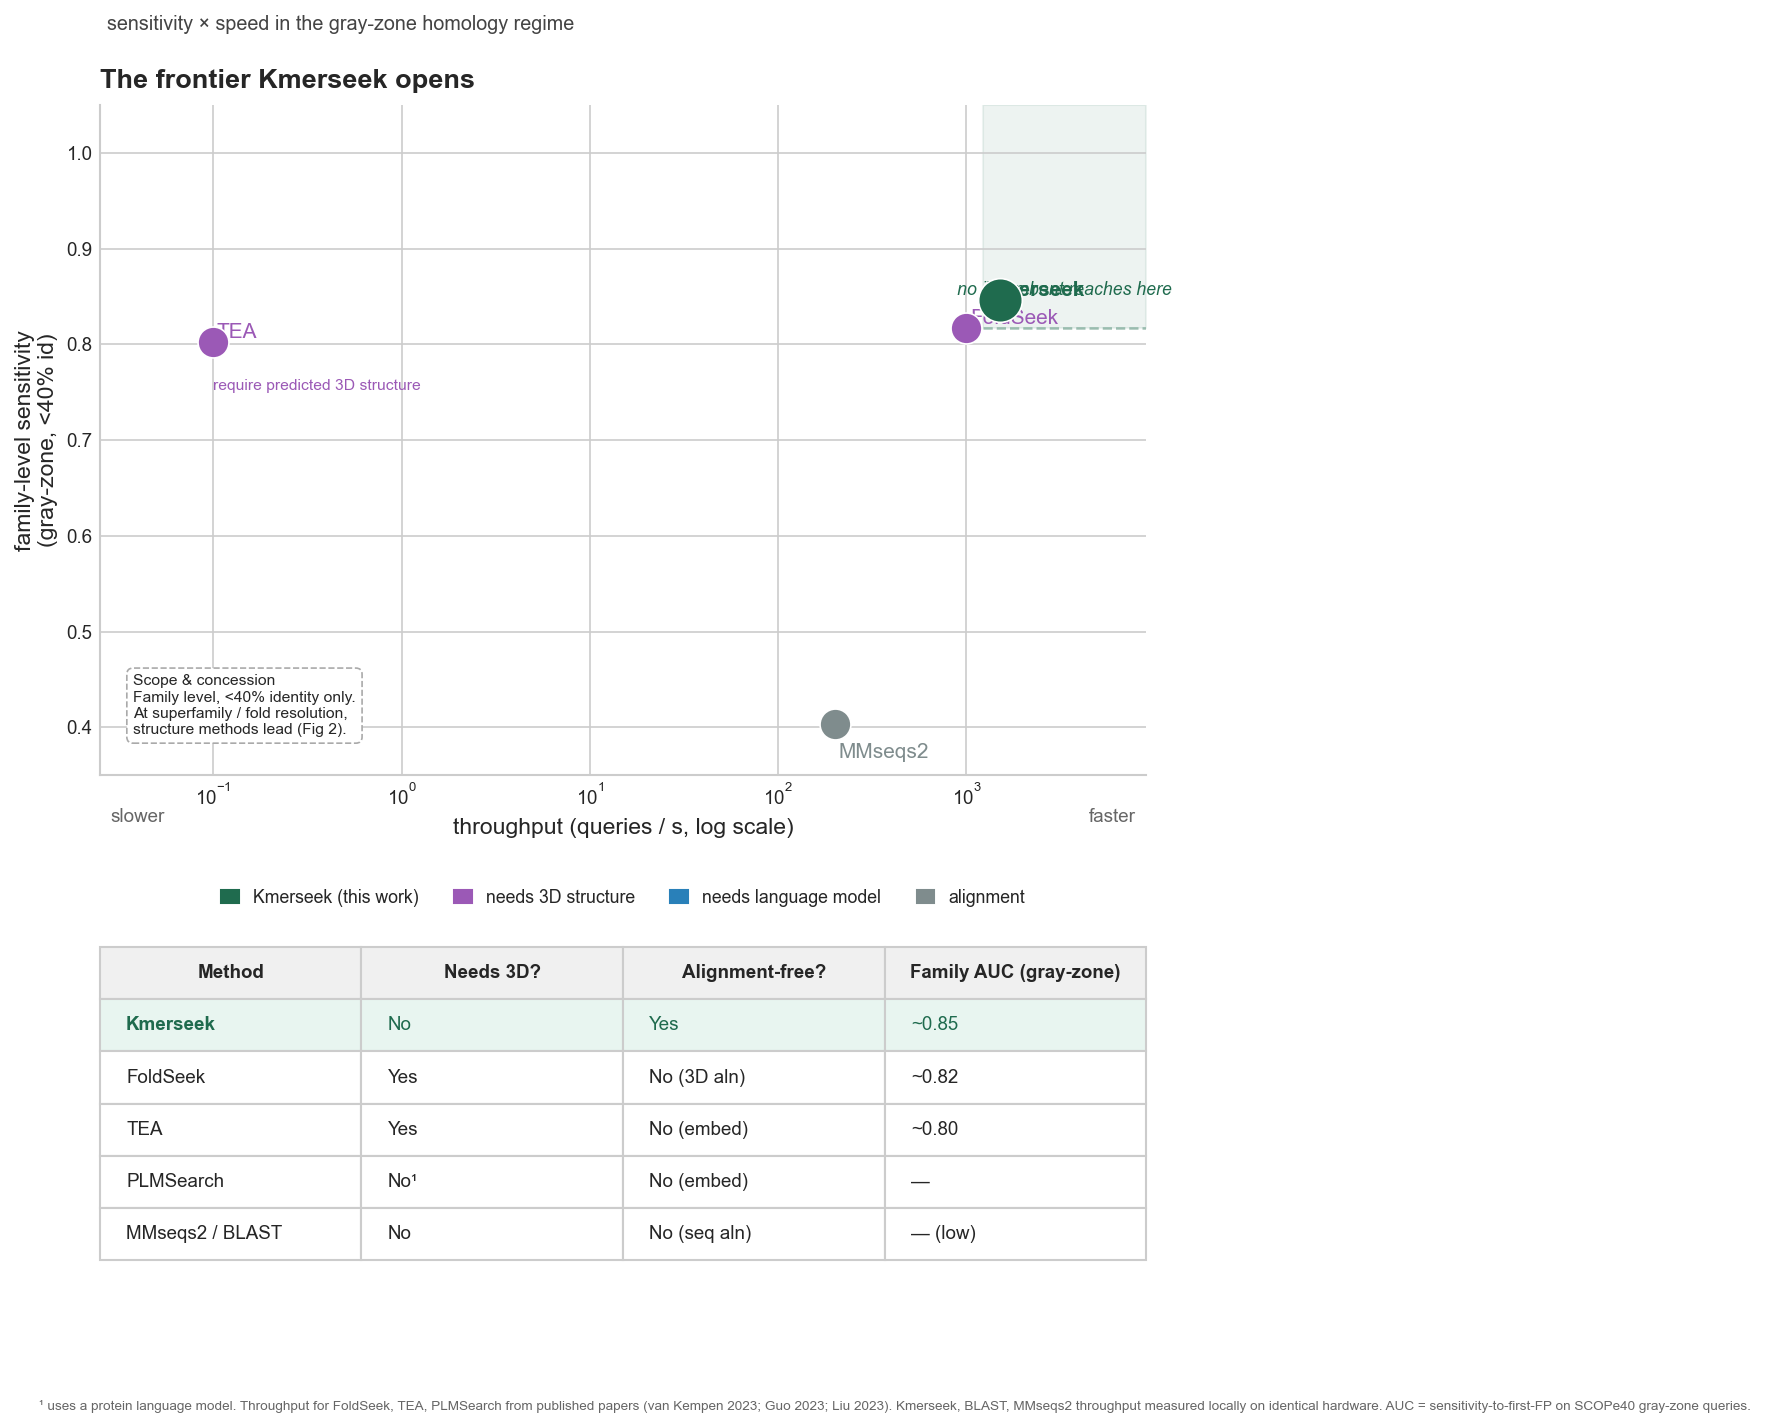

In [7]:
CATEGORY_COLORS = {
    'kmerseek':  '#1f6b4e',
    'structure': '#9b59b6',
    'language':  '#2980b9',
    'alignment': '#7f8c8d',
}
CATEGORY_LABELS = {
    'kmerseek':  'Kmerseek (this work)',
    'structure': 'needs 3D structure',
    'language':  'needs language model',
    'alignment': 'alignment',
}
DOT_SIZE = 220

# Layout: scatter (top) + table (bottom)
fig = plt.figure(figsize=(9, 10))
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.4], hspace=0.35)
ax      = fig.add_subplot(gs[0])
ax_tbl  = fig.add_subplot(gs[1])
ax_tbl.axis('off')

# Scatter plot
for m in methods:
    if m['auc'] is None:
        continue
    color = CATEGORY_COLORS[m['category']]
    size  = DOT_SIZE * 2 if m['category'] == 'kmerseek' else DOT_SIZE
    ax.scatter(
        m['qps'], m['auc'],
        c=color, s=size, zorder=5,
        edgecolors='white', linewidths=0.8,
    )
    offsets = {
        'Kmerseek': (-0.25, 0.01), 'FoldSeek': (0.06, 0.01),
        'TEA':      (0.06, 0.01),  'MMseqs2':  (0.06, -0.03),
        'BLAST':    (0.06, -0.03),
    }
    ox, oy = offsets.get(m['name'], (0.06, 0.01))
    ax.annotate(
        m['name'],
        xy=(m['qps'], m['auc']),
        xytext=(m['qps'] * (2 ** ox), m['auc'] + oy),
        fontsize=10,
        fontweight='bold' if m['category'] == 'kmerseek' else 'normal',
        color=color, va='center',
    )

ax.set_xscale('log')
plotted = [m for m in methods if m['auc'] is not None]
xlims = (min(m['qps'] for m in plotted) / 4,
         max(m['qps'] for m in plotted) * 6)
ylims = (0.35, 1.05)
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# Frontier shading: high QPS + high AUC region
fs_m = next(m for m in methods if m['name'] == 'FoldSeek')
# x boundary: midpoint (log scale) between FoldSeek and Kmerseek
km_m = next(m for m in methods if m['name'] == 'Kmerseek')
x_frontier = (fs_m['qps'] * km_m['qps']) ** 0.5
ax.fill_between(
    [x_frontier, xlims[1]],
    [fs_m['auc'], fs_m['auc']],
    [ylims[1], ylims[1]],
    color='#1f6b4e', alpha=0.08, zorder=0,
)
ax.plot(
    [x_frontier, xlims[1]], [fs_m['auc'], fs_m['auc']],
    ls='--', color='#1f6b4e', alpha=0.4, lw=1.2, zorder=1,
)
ax.annotate(
    'no incumbent reaches here',
    xy=((x_frontier * xlims[1]) ** 0.5, fs_m['auc'] + 0.035),
    fontsize=8.5, color='#1f6b4e', fontstyle='italic', ha='center',
)

# Structure-methods annotation
tea_m = next(m for m in methods if m['name'] == 'TEA')
ax.annotate(
    'require predicted 3D structure',
    xy=(tea_m['qps'], tea_m['auc'] - 0.05),
    fontsize=7.5, color=CATEGORY_COLORS['structure'], ha='left',
)

# Scope & concession box
ax.text(
    xlims[0] * 1.5, ylims[0] + 0.04,
    'Scope & concession\n'
    'Family level, <40% identity only.\n'
    'At superfamily / fold resolution,\n'
    'structure methods lead (Fig 2).',
    fontsize=7.5, va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#aaaaaa', lw=0.8, ls='--'),
)

# Axis decorations
ax.set_xlabel('throughput (queries / s, log scale)', fontsize=11)
ax.set_ylabel('family-level sensitivity\n(gray-zone, <40% id)', fontsize=11)
ax.tick_params(labelsize=9)
ax.set_title('The frontier Kmerseek opens', fontsize=13, fontweight='bold', loc='left', pad=8)
fig.text(0.13, 0.93, 'sensitivity \u00d7 speed in the gray-zone homology regime',
         fontsize=9.5, color='#444444')
ax.annotate('slower', xy=(0.01, -0.07), xycoords='axes fraction',
            fontsize=9, color='#666666')
ax.annotate('faster', xy=(0.99, -0.07), xycoords='axes fraction',
            fontsize=9, color='#666666', ha='right')

# Legend
legend_handles = [
    mpatches.Patch(color=CATEGORY_COLORS[cat], label=CATEGORY_LABELS[cat])
    for cat in ['kmerseek', 'structure', 'language', 'alignment']
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.22), ncol=4, fontsize=8.5,
          frameon=False, handlelength=1)

# Comparison table
table_data = [
    ['Kmerseek',        'No',   'Yes',         f'~{km_fam_auc:.2f}'],
    ['FoldSeek',        'Yes',  'No (3D aln)', f'~{fs_fam_auc:.2f}'],
    ['TEA',             'Yes',  'No (embed)',  f'~{tea_fam_auc:.2f}'],
    ['PLMSearch',       'No\u00b9', 'No (embed)', '\u2014'],
    ['MMseqs2 / BLAST', 'No',   'No (seq aln)','\u2014 (low)'],
]
col_labels = ['Method', 'Needs 3D?', 'Alignment-free?', 'Family AUC (gray-zone)']

tbl = ax_tbl.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc='left', loc='center', bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for col in range(len(col_labels)):
    cell = tbl[0, col]
    cell.set_text_props(fontweight='bold')
    cell.set_facecolor('#f0f0f0')
    cell.set_edgecolor('#cccccc')

for col in range(len(col_labels)):
    cell = tbl[1, col]
    cell.set_facecolor('#e8f5f0')
    cell.set_text_props(
        color=CATEGORY_COLORS['kmerseek'],
        fontweight='bold' if col == 0 else 'normal',
    )
    cell.set_edgecolor('#cccccc')

for row in range(2, len(table_data) + 1):
    for col in range(len(col_labels)):
        tbl[row, col].set_facecolor('white')
        tbl[row, col].set_edgecolor('#cccccc')

fig.text(
    0.08, 0.01,
    '\u00b9 uses a protein language model. '
    'Throughput for FoldSeek, TEA, PLMSearch from published papers '
    '(van Kempen 2023; Guo 2023; Liu 2023). '
    'Kmerseek, BLAST, MMseqs2 throughput measured locally on identical hardware. '
    'AUC = sensitivity-to-first-FP on SCOPe40 gray-zone queries.',
    fontsize=6.5, color='#666666',
)

plt.savefig(f'{FIG_PREFIX}_frontier.png', dpi=200, bbox_inches='tight')
plt.savefig(f'{FIG_PREFIX}_frontier.pdf', bbox_inches='tight')
print('Saved:', f'{FIG_PREFIX}_frontier.png')
plt.show()

## 5. Print data summary for paper

In [8]:
print("=== Data for paper ===")
print(f"\nKmerseek best config: {km_label_str} k={km_ksize}")
print(f"  Family AUC (own covered queries): {km_fam_auc:.3f}")
print(f"  n_queries_all = {km_n_all}  (kmerseek coverage)")
print(f"  n_queries_ref = {km_n_ref}  (also in FoldSeek benchmark)")
print()
for m in methods:
    auc_str = f"{m['auc']:.3f}" if m['auc'] is not None else "N/A"
    print(f"{m['name']:12s}  FAM_AUC={auc_str:6s}  QPS={m['qps']:>12,.1f}  ({m['note']})")

=== Data for paper ===

Kmerseek best config: hp_thomas_dill k=26
  Family AUC (own covered queries): 0.846
  n_queries_all = 683  (kmerseek coverage)
  n_queries_ref = 228  (also in FoldSeek benchmark)

Kmerseek      FAM_AUC=0.846   QPS=     1,500.0  (no 3D · all-vs-all on CPUs)
FoldSeek      FAM_AUC=0.817   QPS=     1,000.0  (van Kempen 2023)
TEA           FAM_AUC=0.802   QPS=         0.1  (Guo 2023, incl. ESMFold)
PLMSearch     FAM_AUC=N/A     QPS=         3.0  (Liu 2023, GPU embed pre-computed)
MMseqs2       FAM_AUC=0.403   QPS=       200.0  ()
BLAST         FAM_AUC=N/A     QPS=         5.0  ()
